In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/NBA_advanced_stats_2002-2022.csv") 
df.head()

,Unnamed: 0,year-name,Pos,Age,Tm,G,MP,PER,TS%,3PAr,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,year
0,0,2003-Tariq Abdul-Wahad,SG,28,DAL,14,204,12.4,0.470,0.017,...,15.0,0.2,0.2,0.4,0.104,-1.6,0.2,-1.4,0.0,2003
1,1,2003-Shareef Abdur-Rahim,PF,26,ATL,81,3087,19.9,0.566,0.051,...,24.2,7.4,2.3,9.7,0.151,2.3,-0.7,1.6,2.8,2003
2,2,2003-Courtney Alexander,PG,25,NOH,66,1360,9.3,0.459,0.113,...,21.3,0.1,1.0,1.1,0.040,-3.3,-1.2,-4.5,-0.9,2003
3,3,2003-Malik Allen,PF,24,MIA,80,2318,9.9,0.455,0.005,...,19.7,-1.7,2.6,0.9,0.018,-3.9,-0.4,-4.4,-1.4,2003
4,4,2003-Ray Allen,SG,27,TOT,76,2880,21.3,0.565,0.391,...,27.8,7.6,1.5,9.1,0.152,4.7,-1.0,3.6,4.1,2003


In [5]:
giannis = df[df['year-name'].str.contains("Giannis Antetokounmpo", case=False, na=False) & 
             df["year"].between(2016,2022)
].copy()

giannis[["year","Tm","Pos","MP","PER","TS%","WS","BPM","VORP"]]

,year,Tm,Pos,MP,PER,TS%,WS,BPM,VORP
7518,2016,MIL,PG,2823,18.8,0.566,7.1,2.1,2.9
8095,2017,MIL,SF,2845,26.1,0.599,12.4,7.3,6.7
8686,2018,MIL,PF,2756,27.3,0.598,11.9,6.2,5.7
9354,2019,MIL,PF,2358,30.9,0.644,14.4,10.4,7.4
10055,2020,MIL,PF,1917,31.9,0.613,11.1,11.5,6.6
10711,2021,MIL,PF,2013,29.2,0.633,10.2,9.0,5.6
11414,2022,MIL,PF,2204,32.1,0.633,12.9,11.2,7.4


In [6]:
peers = df[
    df["year"].between(2016,2022) &
    df["Pos"].isin(["PF", "SF"]) & 
    (df["MP"] >= 1500)
].copy()

peers = peers[~peers["year-name"].str.contains("Giannis Antetokounmpo", case=False, na=False)]
peers.shape

(469, 28)

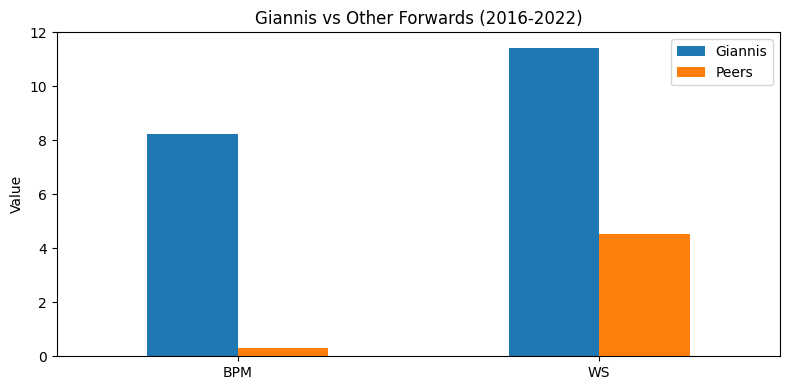

In [7]:
import matplotlib.pyplot as plt
import pandas as pd


comparison = pd.DataFrame({
    "Giannis": [
        giannis["PER"].mean(),
        giannis["TS%"].mean() * 100,
        giannis["BPM"].mean(),
        giannis["WS"].mean()

    ],
    "Peers":[
        peers["PER"].mean(),
        peers["TS%"].mean() * 100,
        peers["BPM"].mean(),
        peers["WS"].mean()
    ]
}, index=["PER", "TS%", "BPM", "WS"])

#Chart 1: BPM and WS

comparison.loc[["BPM","WS"]].plot(kind="bar", figsize=(8,4))
plt.title("Giannis vs Other Forwards (2016-2022)")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()








Takeaway:
Giannis significantly outperforms other forwards in both BPM (Box Plus-Minus) and WS (Win Shares) which shows that his value comes from sustained, two-way impact that translates to winning. Giannis is not only individually performing, but he contributes tremendously to winning due to his two-way impact. 

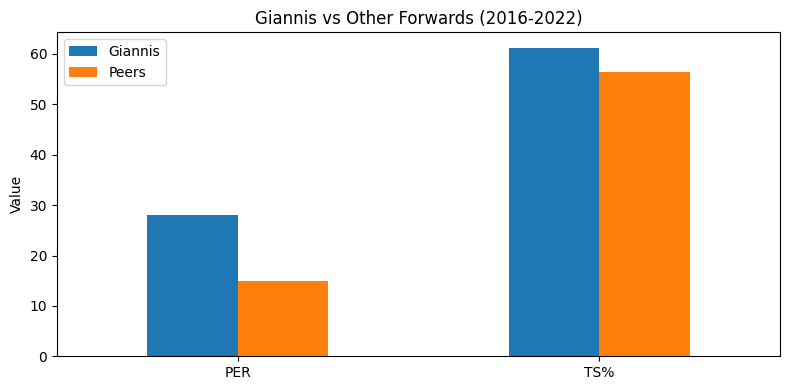

In [8]:
#Chart 2: PER and TS%

comparison.loc[["PER", "TS%"]].plot(kind="bar", figsize=(8,4))
plt.title("Giannis vs Other Forwards (2016-2022)")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Takeaway: 
While Giannis is shown to be more efficient than other forwards as indicated by his PER (Player Efficiency Rating), the gap in his TS% (True Shooting Percentage) is relatively modest compared to his separation in impact metrics. This suggests that his dominance is driven more by his contributions on both sides of the ball than just scoring alone. 